## need to validate equation 5 and (basically) the volume transport.

Notes post An meeting 3/6:
- think about this in terms of limits
- we will need to run this a couple of times with a different dT and dS for the bins
- maybe we can turn this into a manual based on input dT and dS -- show the residual is bigger as the dT approaches 0

## Set up the grid

In [60]:
# going to try to run this with the validated J terms for a single cell.

In [61]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(450, 90)
RAC2d (40500,)
(100,)


In [62]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [63]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

## decide the width of the T bins

I don't want to read this from file, I want to do this by reading from the bin edges and defining the number of bins we want in T and S.

In [64]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

# --- Define bin count and recompute uniform edges ---
# adding a number of bins here will allow us to perform the limit for small/large nT or nS
nT = 70
nS = 70

nT = 150
nS = 150

#T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
#S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS
T_edges = _T_edges_raw
S_edges = _S_edges_raw
nT,nS = 112,112

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Tbin3,Sbin3 = np.meshgrid(bincentTp,bincentSp) # for plotting the convergence of the J vectors

In [65]:
# dT_centers

In [66]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [67]:
# create the iwet for a specific, singular column with two cells.
iy,ix = 150,19

In [68]:
# create iwet from a mask at these points
mymsk = np.full((ny,nx),np.nan)
mymsk[iy,ix] = 1
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [69]:
mymsk_faces = get_aste_faces(mymsk,nfx,nfy)
a = mymsk_faces.f3[0]
np.where(~np.isnan(a))                               # double checking this is the same one An has provided

(array([0]), array([19]))

## Load the (previously validated) J terms

In [70]:
# plt.pcolormesh(mymsk)

In [71]:
# create the same Jy offline as done before

from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

dt = 1800
MsumT,termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
MsumS,termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)


In [72]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

In [73]:
# double check An's idea about having 3 diff TS bins
print(THETA[:3,iy,ix])
tC = (THETA[:3,iy,ix])
print(0.5*(tC + THETA[:3,iy+1,ix]))
print(0.5*(tC + THETA[:3,iy,ix-1]))

print()

print(SALT[:3,iy,ix])
sC = (SALT[:3,iy,ix])
print(0.5*(sC + SALT[:3,iy+1,ix]))
print(0.5*(sC + SALT[:3,iy,ix-1]))

[-1.82381129 -1.82459402  0.        ]
[-1.80780178 -1.81442577  0.        ]
[-1.80865788 -1.80403185 -0.88456899]

[33.32093048 33.33365631  0.        ]
[33.02385712 33.22032166  0.        ]
[33.05558586 33.30172348 16.72927666]


In [74]:
print(binmidS[83:86])
print(binmidT[:3])   # everything is in the same T bin (iT=1)
boundsS.flatten()[83:86]

[32.875 33.125 33.375]
[-2.60000002 -2.20000005 -1.80000001]


array([32.75, 33.  , 33.25])

In [75]:
def bin_3d_term_to_TS(term3d, THETA, SALT, mymsk3d, binmidT, binmidS, binwidthT1, binwidthS1):
    nT = len(binmidT)
    nS = len(binmidS)

    dF_TS = np.zeros((nT-1, nS-1), dtype=float)
    L_TS  = np.zeros((nT-1, nS-1), dtype=int)

    # Flatten
    T_flat = np.ravel(THETA * mymsk3d, order="F")
    S_flat = np.ravel(SALT  * mymsk3d, order="F")
    X_flat = np.ravel(term3d * mymsk3d, order="F")

    # Bin indices
    iT = np.searchsorted(binmidT, T_flat, side="right") - 1
    iS = np.searchsorted(binmidS, S_flat, side="right") - 1

    # Valid points
    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(X_flat)
    iT = iT[ok]
    iS = iS[ok]
    vals = X_flat[ok]

    # Accumulate
    np.add.at(dF_TS, (iT, iS), vals)
    np.add.at(L_TS,  (iT, iS), 1)

    # Normalize by both bin widths
    dA = binwidthT1[:, None] * binwidthS1[None, :]  # An suggests doing this separately in future
                                                    # first division in dT or dS gets you G_T or G_S
                                                    # second division by dS or dT gets you the J component of J_S or J_T
    G_TS = dF_TS / dA                               # should not be called G_TS here!

    return G_TS, dF_TS, L_TS

termsT_TS = {}   # inputs as degC.m^3/s, out as m^3/s/PSU, same as layers Jy
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

termsS_TS = {}   # inputs as PSU.m^3/s, out as m^3/s/degC, same as layers Jx
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

In [76]:
np.where(termsT_TS['tend']!=0)

(array([1]), array([84]))

In [77]:
# # get the M term as a TS diagram for the T and S
# # there are two gates, and two face temperature values
# TH_N = (THETA[:,iy,ix] + THETA[:,iy+1,ix])/2
# TH_W = (THETA[:,iy,ix] + THETA[:,iy,ix-1])/2

# SLT_N = (SALT[:,iy,ix] + SALT[:,iy+1,ix])/2
# SLT_W = (SALT[:,iy,ix] + SALT[:,iy,ix-1])/2

# print(TH_N[:2], TH_W[:2], SLT_N[:2], SLT_W[:2])

# print(T_centers[1:3])     # for both bins at iT
# print(S_centers[83:85])   # for the top and bottom bins in SLT

In [78]:
# define ADVy and ADVx

# get the Msum from ADVx and ADVy of the terms
file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH","ADVx_SLT","ADVy_SLT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
ADVx_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
ADVy_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[3])

ADVx_TH = ADVx_TH.reshape((nz,ny,nx)) # degC.m^3/s
ADVy_TH = ADVy_TH.reshape((nz,ny,nx)) 
ADVx_SLT = ADVx_SLT.reshape((nz,ny,nx)) # PSU.m^3/s
ADVy_SLT = ADVy_SLT.reshape((nz,ny,nx))

In [79]:
def bin_face_flux_to_TS(flux_z, T_face_z, S_face_z, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d=None):
    """
    Bin a vertical column of face fluxes into (T,S) space.
    flux_z, T_face_z, S_face_z are all 1D arrays of length nz.
    """
    nT = len(binmidT)
    nS = len(binmidS)
    dF_TS = np.zeros((nT-1, nS-1), dtype=float)

    if mymsk1d is not None:
        valid = mymsk1d.astype(bool)
        flux_z   = flux_z[valid]
        T_face_z = T_face_z[valid]
        S_face_z = S_face_z[valid]

    # Bin indices using same logic as bin_3d_term_to_TS
    iT = np.searchsorted(binmidT, T_face_z, side="right") - 1
    iS = np.searchsorted(binmidS, S_face_z, side="right") - 1

    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(flux_z)
    np.add.at(dF_TS, (iT[ok], iS[ok]), flux_z[ok])

    # Normalize by bin areas
    dA = binwidthT1[:, None] * binwidthS1[None, :]
    return dF_TS / dA, dF_TS


# --- Face-averaged T and S at each gate ---
TH_N  = (THETA[:,iy,ix] + THETA[:,iy+1,ix]) / 2   # north gate
TH_W  = (THETA[:,iy,ix] + THETA[:,iy,ix-1]) / 2   # west gate
SLT_N = (SALT[:,iy,ix]  + SALT[:,iy+1,ix])  / 2
SLT_W = (SALT[:,iy,ix]  + SALT[:,iy,ix-1])  / 2

# --- Raw face fluxes (sign convention: into the cell is positive) ---
M_NT_z = -ADVy_TH[:,iy+1,ix]    # north face, heat
M_NS_z = -ADVy_SLT[:,iy+1,ix]   # north face, salt
M_WT_z =  ADVx_TH[:,iy,ix]      # west face,  heat
M_WS_z =  ADVx_SLT[:,iy,ix]     # west face,  salt

mymsk1d = mymsk3d[:,iy,ix]  # 1D mask for this column

# --- Bin each gate flux by face-averaged (T,S) ---
M_T_N, _ = bin_face_flux_to_TS(M_NT_z, TH_N,  SLT_N, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)
M_T_W, _ = bin_face_flux_to_TS(M_WT_z, TH_W,  SLT_W, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)
M_S_N, _ = bin_face_flux_to_TS(M_NS_z, TH_N,  SLT_N, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)
M_S_W, _ = bin_face_flux_to_TS(M_WS_z, TH_W,  SLT_W, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)

# --- Sum gates to get total M_T and M_S ---
M_T = M_T_N + M_T_W   # [nTm1, nSm1]
M_S = M_S_N + M_S_W   # [nTm1, nSm1]

# --- Sanity check: print the bins at the known point ---
print("M_T sum:", np.nansum(M_T)*1e-6)        # Sv/PSU
print("M_S sum:", np.nansum(M_S)*1e-6)        # Sv/degC
# these should be the same values as ADVh, yes this is verified.

M_T sum: -0.011951184761169527
M_S sum: 0.20827634310384163


In [80]:
print(np.nansum(M_T_N)*1e-6)
print(np.nansum(M_T_W)*1e-6)

-0.19400996591525063
0.1820587811540811


In [81]:
print(M_T_N[1,83]*1e-6,M_T_N[1,84]*1e-6)
print(M_T_W[1,83]*1e-6,M_T_W[1,84]*1e-6)
print()
print(M_S_N[1,83]*1e-6,M_S_N[1,84]*1e-6)
print(M_S_W[1,83]*1e-6,M_S_W[1,84]*1e-6)

-0.12731462298280835 -0.06669534293244231
0.10314033036469811 0.07891845078938302

2.325001615300976 1.2198250667336088
-1.8848038238458622 -1.4517465150848807


In [82]:
# quickly validate the gate term again here with ADVh
print(np.nansum(termsT_TS["ADVh"])*1e-6,"Sv/PSU") # this is the Jy which we want to difference in T
print(np.nansum(termsS_TS["ADVh"])*1e-6,"Sv/degC")

-0.011951184761169518 Sv/PSU
0.20827634310384174 Sv/degC


In [83]:
#print out the gateway and center THETA and SALT terms
print(TH_N[:3],TH_W[:3],THETA[:,iy,ix][:2])
print(SLT_N[:3],SLT_W[:3],SALT[:,iy,ix][:2])

[-1.80780178 -1.81442577  0.        ] [-1.80865788 -1.80403185 -0.88456899] [-1.82381129 -1.82459402]
[33.02385712 33.22032166  0.        ] [33.05558586 33.30172348 16.72927666] [33.32093048 33.33365631]


In [84]:
print( -ADVy_TH[:,iy+1,ix][:2])    # north face, heat
print(-ADVy_SLT[:,iy+1,ix][:2]  ) # north face, salt
print( ADVx_TH[:,iy,ix][:2]  )    # west face,  heat
print( ADVx_SLT[:,iy,ix][:2]  )   # west face,  salt

[-12731.46343656  -6669.53488955]
[232500.18231723 121982.51757945]
[10314.03395862  7891.84578452]
[-188480.39923605 -145174.66448811]


## now plot the divergence of these terms

In [85]:
# # write an example function which takes the Jy (T in Sv/PSU) term and the Jx (S in Sv/degC) term and returns the divergence
# # as normalized by the dT_edges[1:-1] (shape nT-2)

# def get_div(Jy, Jx, dT_edges, dS_edges):
#     '''
#     inputs:
#         Jy: transport in T direction, shape (nT-1, nS-1), units of m^3/s/PSU
#         Jx: transport in S direction, shape (nT-1, nS-1), units of m^3/s/degC
#         dT_edges: T-bin widths for interior T differences, shape (nT-2,)
#         dS_edges: S-bin widths for interior S differences, shape (nS-2,)

#     outputs:
#         gradJ: divergence on interior cell centers, shape (nT-2, nS-2), units of Sv/PSU/degC
#     '''

#     # Difference in T direction: shape (nT-2, nS-1)
#     dJy = Jy[1:, :] - Jy[:-1, :]            # m^3/s/PSU

#     # Difference in S direction: shape (nT-1, nS-2)
#     dJx = Jx[:, 1:] - Jx[:, :-1]            # m^3/s/degC

#     # Divide by bin widths
#     # dT_edges[:, None] broadcasts across S
#     dJydT = dJy / dT_edges[1:-1, None]      # (nT-2, nS-1);  m^3/s/PSU -->   m^3/s/PSU/degC

#     # dS_edges[None, :] broadcasts across T
#     dJxdS = dJx / dS_edges[None, 1:-1]      # (nT-1, nS-2);  m^3/s/degC -->  m^3/s/degC/PSU

#     # Center to common interior points (nT-2, nS-2) -- this is wrong
#     # 
#     dJydT_center = 0.5 * (dJydT[:, 1:] + dJydT[:, :-1])
#     dJxdS_center = 0.5 * (dJxdS[1:, :] + dJxdS[:-1, :])

#     gradJ = -(dJydT_center + dJxdS_center)                # we set so that + is creation

#     return gradJ * 1e-6                                   # Sv/PSU/degC


In [86]:
def get_div(Jy, Jx, dT_edges, dS_edges):
    """
    inputs:
        Jy: transport in T direction, shape (nT-1, nS-1), units m^3/s/PSU
            defined on center of T_centers,S_centers
        Jx: transport in S direction, shape (nT-1, nS-1), units m^3/s/degC
            defined on center of T_centers,S_centers
        dT_edges: T-bin widths at interior T intervals, shape (nT-1,) or compatible
        dS_edges: S-bin widths at interior S intervals, shape (nS-1,) or compatible

    outputs:
        gradJ: divergence on interior cell centers, shape (nT-2, nS-2),
               units Sv/PSU/degC
    """

    # Interpolate fluxes onto the INNER faces of the interior cells first
    # Jy_inner: top/bottom faces for interior cells, remove outer S columns
    Jy_inner = 0.5 * (Jy[1:, :] + Jy[:-1, :])   # shape (nT-2, nS-1)   # bring these up to the inner face  (in temp)

    # Jx_inner: left/right faces for interior cells, remove outer T rows
    Jx_inner = 0.5 * (Jx[:, 1:] + Jx[:, :-1])   # shape (nT-2, nS-1)   # bring these to the inner faces LR (in salt)

    # Then take differences across those inner faces
    # check this is the correct sign for + in
    print(np.where(Jy_inner != 0))
    print(np.where(Jx_inner != 0))
    dJy = Jy_inner[1:, :] - Jy_inner[:-1, :]    # shape (nT-3, nS-2)
    dJx = Jx_inner[:, 1:] - Jx_inner[:, :-1]    # shape (nT-2, nS-3)
    print()
    print(np.where(dJy !=0))
    print(np.where(dJx !=0))

    # Divide by bin widths
    dJydT = dJy / dT_centers[1:-1, None]
    dJxdS = dJx / dS_centers[None, 1:-1]

    
    print()

    print(np.where(dJydT!=0),np.where(dJxdS!=0))

    # Negative so positive means creation
    gradJ = -(dJydT[:,1:-1] + dJxdS[1:-1,:])

    return gradJ * 1e-6   # Sv/PSU/degC

divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_edges, dS_edges)
print(np.where(divADVh!=0))

(array([0, 1]), array([84, 84]))
(array([1, 1]), array([83, 84]))

(array([1]), array([84]))
(array([1, 1]), array([82, 84]))

(array([1]), array([84])) (array([1, 1]), array([82, 84]))
(array([0, 0, 1]), array([82, 84, 83]))


In [87]:
termsT_TS['ADVh'].shape
dT_edges.shape
dT_centers[1:-1, None].shape

(109, 1)

In [88]:
# load the grad ADVh from the online terms
# print(divADVh[divADVh!= 0])
# print(np.where(divADVh!=0))

In [89]:
termsT_TS['ADVh'][termsT_TS['ADVh']!=0] # at iT = 1, iS = 84     this is Jy in terms of m^3/s/PSU

array([-11951.18476117])

In [90]:
termsS_TS['ADVh'][termsS_TS['ADVh']!=0]  # at iT = 1, iS = 84    this is Jx in terms of m^3/s/degC

array([208276.34310384])

In [91]:
Jy_advh = termsT_TS['ADVh']
Jx_advh = termsS_TS['ADVh']

In [92]:
# now get the same for the printed M term
div_gates = get_div(M_T,M_S,dT_edges,dS_edges)
print(div_gates[div_gates!= 0])
print(np.where(div_gates!=0))

div_gatesN = get_div(M_T_N,M_S_N,dT_edges,dS_edges)
div_gatesW = get_div(M_T_W,M_S_W,dT_edges,dS_edges)

(array([0, 0, 1, 1]), array([83, 84, 83, 84]))
(array([1, 1, 1]), array([82, 83, 84]))

(array([1, 1]), array([83, 84]))
(array([1, 1, 1, 1]), array([81, 82, 83, 84]))

(array([1, 1]), array([83, 84])) (array([1, 1, 1, 1]), array([81, 82, 83, 84]))
[-0.88039558  0.4638429   0.88039558 -0.4638429  -0.04029049  0.02037185]
(array([0, 0, 0, 0, 1, 1]), array([81, 82, 83, 84, 82, 83]))
(array([0, 0, 1, 1]), array([83, 84, 83, 84]))
(array([1, 1, 1]), array([82, 83, 84]))

(array([1, 1]), array([83, 84]))
(array([1, 1, 1, 1]), array([81, 82, 83, 84]))

(array([1, 1]), array([83, 84])) (array([1, 1, 1, 1]), array([81, 82, 83, 84]))
(array([0, 0, 1, 1]), array([83, 84, 83, 84]))
(array([1, 1, 1]), array([82, 83, 84]))

(array([1, 1]), array([83, 84]))
(array([1, 1, 1, 1]), array([81, 82, 83, 84]))

(array([1, 1]), array([83, 84])) (array([1, 1, 1, 1]), array([81, 82, 83, 84]))


In [93]:
T_keys = list(termsT_TS.keys())
S_keys = list(termsS_TS.keys())

# total tendency
dVdt = get_div(termsT_TS['tend'], termsS_TS['tend'], dT_edges, dS_edges)

# example single term
divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_edges, dS_edges)

divDFh = get_div(termsT_TS['DFhT'], termsS_TS['DFhS'], dT_edges, dS_edges)


# internal = sum of terms at positions 1,2,3,5
internal_inds = [1, 2, 3, 5]

divint = sum(
    get_div(termsT_TS[T_keys[i]], termsS_TS[S_keys[i]], dT_edges, dS_edges)
    for i in internal_inds
)

# surface = term at position 4
surface_ind = 4
divsurf = get_div(
    termsT_TS[T_keys[surface_ind]],
    termsS_TS[S_keys[surface_ind]],
    dT_edges,
    dS_edges
)

# div_gates = get_div(M_T,M_S,dT_edges,dS_edges)

(array([0, 1]), array([84, 84]))
(array([1, 1]), array([83, 84]))

(array([1]), array([84]))
(array([1, 1]), array([82, 84]))

(array([1]), array([84])) (array([1, 1]), array([82, 84]))
(array([0, 1]), array([84, 84]))
(array([1, 1]), array([83, 84]))

(array([1]), array([84]))
(array([1, 1]), array([82, 84]))

(array([1]), array([84])) (array([1, 1]), array([82, 84]))
(array([0, 1]), array([84, 84]))
(array([1, 1]), array([83, 84]))

(array([1]), array([84]))
(array([1, 1]), array([82, 84]))

(array([1]), array([84])) (array([1, 1]), array([82, 84]))
(array([], dtype=int64), array([], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))

(array([], dtype=int64), array([], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))

(array([], dtype=int64), array([], dtype=int64)) (array([], dtype=int64), array([], dtype=int64))
(array([0, 1]), array([84, 84]))
(array([1, 1]), array([83, 84]))

(array([1]), array([84]))
(array([1, 1]), array([82, 84]))

(array([1]), array(

In [94]:
print(dVdt[dVdt!=0])
print()
print(divADVh[divADVh!=0])
print(divint[divint!=0])
print(divsurf[divsurf!=0])
print(np.nansum(divADVh) + np.nansum(divint) + np.nansum(divsurf))

print()
print("resid",np.nansum(divADVh) + np.nansum(divint) + np.nansum(divsurf)- dVdt[dVdt!=0])

print()
print(div_gatesN[div_gatesN!=0])
print(div_gatesW[div_gatesW!=0])
print(np.nansum(div_gatesN) + np.nansum(div_gatesW))



[-0.27263505  0.27263505 -0.01900307]

[-0.41655269  0.41655269 -0.01991864]
[-6.16187594e-06  6.16187594e-06  1.67974876e-04]
[ 0.1439238 -0.1439238  0.0007476]
-0.01900306862053972

resid [ 2.53631978e-01 -2.91638116e-01  1.39679934e-13]

[-4.65000323 -2.43965013  4.65000323  2.43965013 -0.21219103 -0.1111589 ]
[ 3.76960765  2.90349303 -3.76960765 -2.90349303  0.17190054  0.13153075]
-0.019918640477119776


(-2.0, 0.0)

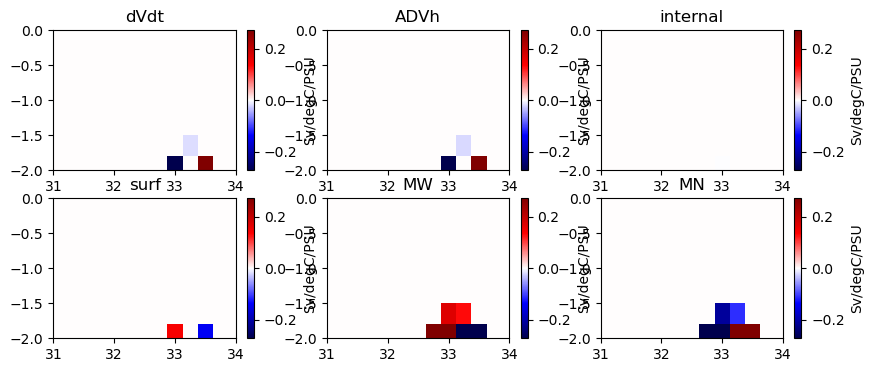

In [95]:
fig = plt.figure()

# plot each of the above and a sum of them

ax = plt.subplot(231)
lhs = dVdt
vlev = np.nanmin(dVdt)
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],dVdt.T,cmap='seismic',vmin=vlev,vmax=-vlev)
ax.set_title("dVdt")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(232)
ax.set_title("ADVh")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],divADVh.T,cmap='seismic',vmin=vlev,vmax=-vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(233)
ax.set_title("internal")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],divint.T,cmap='seismic',vmin=vlev,vmax=-vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(234)
ax.set_title("surf")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],divsurf.T,cmap='seismic',vmin=vlev,vmax=-vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(235)
ax.set_title("MW")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],div_gatesW.T,cmap='seismic',vmin=vlev,vmax=-vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(236)
ax.set_title("MN")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],div_gatesN.T,cmap='seismic',vmin=vlev,vmax=-vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

In [49]:
np.where(dVdt.T != 0) 

(array([82, 83, 84]), array([0, 1, 0]))

In [55]:
dVdt.T[82,0]

-0.27263504692346535

In [56]:
dVdt.T[83,1]

-0.0190030686206794

In [57]:
dVdt.T[84,0]

0.27263504692346535

In [59]:
fields = {
    "dVdt": dVdt,
    "ADVh": divADVh,
    "internal": divint,
    "surf": divsurf,
    "MW": div_gatesW,
    "MN": div_gatesN,
}

for name, arr in fields.items():
    print(f"\n--- {name} ---")
    
    arr = np.asarray(arr)
    mask = np.isfinite(arr) & (arr != 0)
    inds = np.argwhere(mask)
    
    if inds.size == 0:
        print("No nonzero values")
        continue
    
    for i, j in inds:
        print(f"(T_idx={i}, S_idx={j})  value={arr[i, j]}")


--- dVdt ---
(T_idx=0, S_idx=82)  value=-0.27263504692346535
(T_idx=0, S_idx=84)  value=0.27263504692346535
(T_idx=1, S_idx=83)  value=-0.0190030686206794

--- ADVh ---
(T_idx=0, S_idx=82)  value=-0.4165526862076835
(T_idx=0, S_idx=84)  value=0.4165526862076835
(T_idx=1, S_idx=83)  value=-0.019918640477120206

--- internal ---
(T_idx=0, S_idx=82)  value=-6.161875938000579e-06
(T_idx=0, S_idx=84)  value=6.161875938000579e-06
(T_idx=1, S_idx=83)  value=0.00016797487582645535

--- surf ---
(T_idx=0, S_idx=82)  value=0.14392380116638204
(T_idx=0, S_idx=84)  value=-0.14392380116638204
(T_idx=1, S_idx=83)  value=0.0007475969807540308

--- MW ---
(T_idx=0, S_idx=81)  value=3.7696076476917244
(T_idx=0, S_idx=82)  value=2.903493030169761
(T_idx=0, S_idx=83)  value=-3.7696076476917235
(T_idx=0, S_idx=84)  value=-2.9034930301697615
(T_idx=1, S_idx=82)  value=0.17190054377711628
(T_idx=1, S_idx=83)  value=0.13153074608907608

--- MN ---
(T_idx=0, S_idx=81)  value=-4.650003230601952
(T_idx=0, S_id

(-2.0, 0.0)

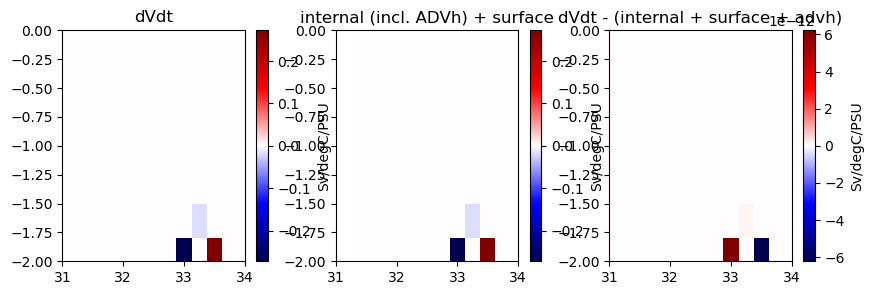

In [47]:
fig = plt.figure(figsize=(10,3))

# plot each of the above and a sum of them

ax = plt.subplot(131)
lhs = dVdt
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],dVdt.T,cmap='seismic',vmin=vlev,vmax=-vlev)
ax.set_title("dVdt")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(132)
rhs = divADVh + divint + divsurf
ax.set_title("internal (incl. ADVh) + surface")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],rhs.T,cmap='seismic',vmin=vlev,vmax=-vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(133)
ax.set_title("dVdt - (internal + surface + advh)")
cb = ax.pcolormesh(Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1],(rhs-lhs).T,cmap='seismic')
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

Text(0.5, 0.98, 'Residual at dT=0.40 and dS=1.00')

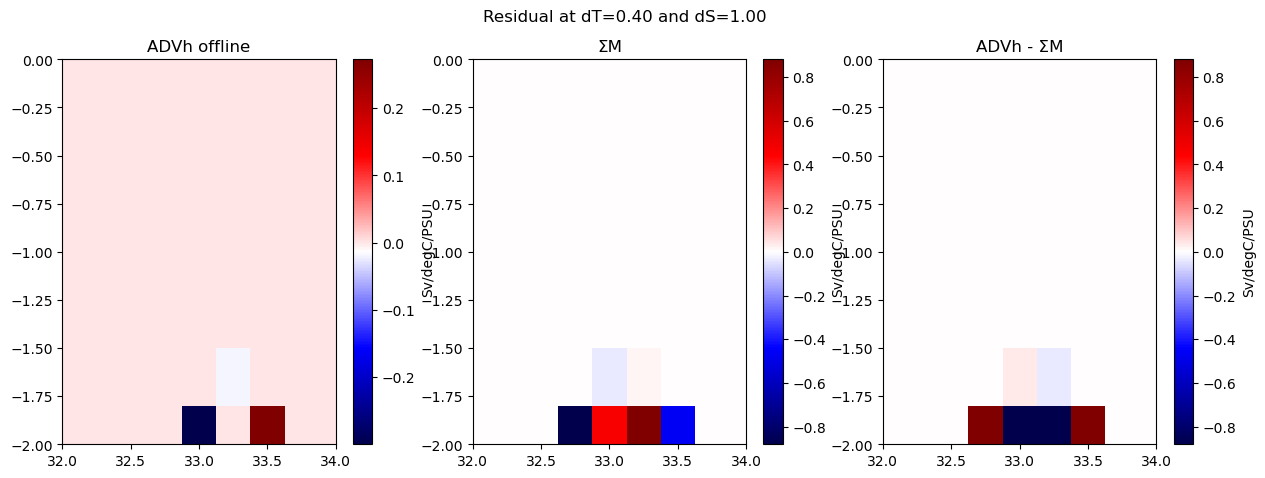

In [118]:
# great, now look at the gateway term in TS as compared to the ADVh term
fig = plt.figure(figsize=(15,5))

# plot each of the above and a sum of them
ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin3,Tbin3,divADVh.T,cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_title("ADVh offline")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(32,34)
ax.set_ylim(-2,0)

ax = plt.subplot(132)
vlev = np.nanmax(div_gates)
cb = ax.pcolormesh(Sbin3,Tbin3,div_gates.T,cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_title("ΣM")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(32,34)
ax.set_ylim(-2,0)

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin3,Tbin3,(divADVh-div_gates).T,cmap='seismic')#,vmin=-3,vmax=3)
ax.set_title("ADVh - ΣM")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(32,34)
ax.set_ylim(-2,0)

plt.suptitle(f"Residual at dT={dT_centers[0]:.2f} and dS={dS_centers[0]:.2f}")


In [119]:
print(np.nanmax((divADVh-div_gates)),"Sv/degC/PSU")
print(np.nanmin((divADVh-div_gates)),"Sv/degC/PSU") # yes because these are being binned to the same value

0.8803955829102272 Sv/degC/PSU
-0.8803955829102272 Sv/degC/PSU


Text(0.5, 0, 'S_edges[2:-2], nS-2, PSU')

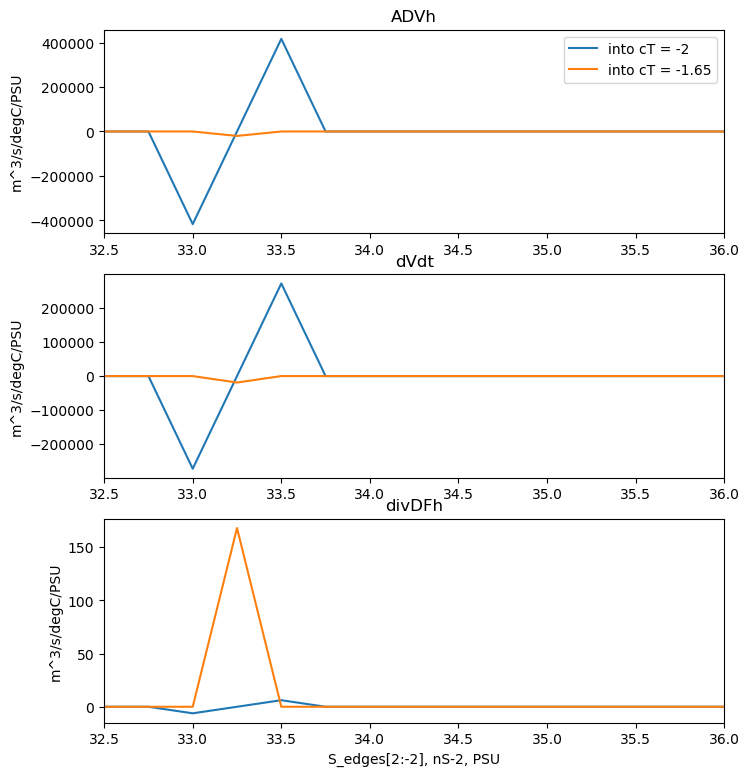

In [122]:
# try to plot the same as An has done (collapse in dimension 0 for ADVh and DFh)

fig = plt.figure(figsize = (8,9))

ax = plt.subplot(311)
advhred = divADVh[0]
advhblue = divADVh[1]
xS = S_edges[2:-2]
ax.plot(xS,advhred*1e6,label="into cT = -2")
ax.plot(xS,advhblue*1e6,label="into cT = -1.65")
ax.set_xlim(32.5,36)
ax.set_ylabel("m^3/s/degC/PSU")
ax.set_title("ADVh")
ax.legend()


ax = plt.subplot(312)
advhred = dVdt[0]
advhblue = dVdt[1]
xS = S_edges[2:-2]
ax.plot(xS,advhred*1e6,label="into cT = -2")
ax.plot(xS,advhblue*1e6,label="into cT = -1.65")
ax.set_xlim(32.5,36)
ax.set_ylabel("m^3/s/degC/PSU")
ax.set_title("dVdt")

ax = plt.subplot(313)
advhred = divDFh[0]
advhblue = divDFh[1]
xS = S_edges[2:-2]
ax.plot(xS,advhred*1e6,label="into cT = -2")
ax.plot(xS,advhblue*1e6,label="into cT = -1.65")
ax.set_xlim(32.5,36)
ax.set_ylabel("m^3/s/degC/PSU")
ax.set_title("divDFh")
ax.set_xlabel("S_edges[2:-2], nS-2, PSU")

Text(0.5, 1.0, 'gates')

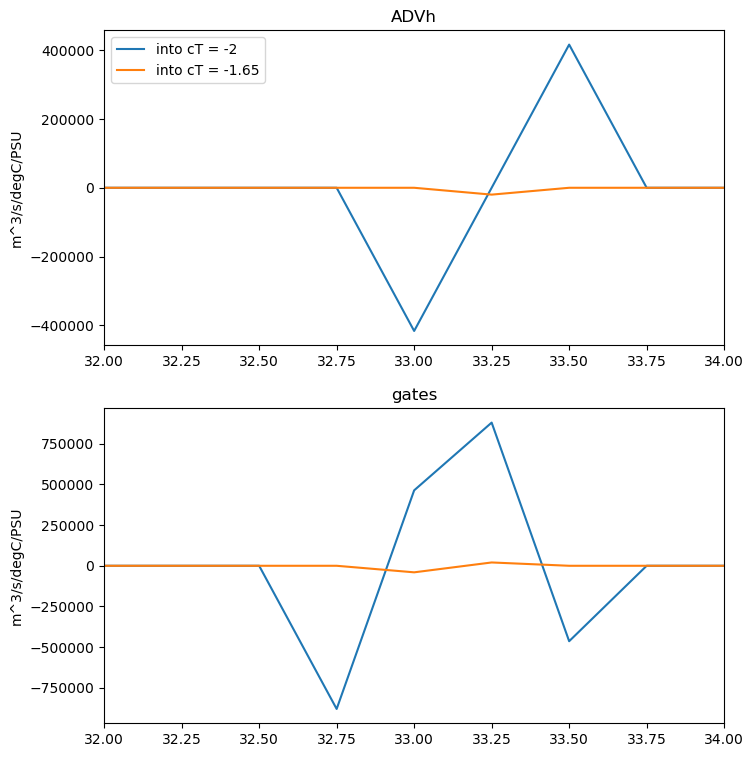

In [124]:

fig = plt.figure(figsize = (8,9))

ax = plt.subplot(211)
advhred = divADVh[0]
advhblue = divADVh[1]
xS = S_edges[2:-2]
ax.plot(xS,advhred*1e6,label="into cT = -2")
ax.plot(xS,advhblue*1e6,label="into cT = -1.65")
ax.set_xlim(32,34)
ax.set_ylabel("m^3/s/degC/PSU")
ax.set_title("ADVh")
ax.legend()


ax = plt.subplot(212)
advhred = div_gates[0]
advhblue = div_gates[1]
xS = S_edges[2:-2]
ax.plot(xS,advhred*1e6,label="into cT = -2")
ax.plot(xS,advhblue*1e6,label="into cT = -1.65")
ax.set_xlim(32,34)
ax.set_ylabel("m^3/s/degC/PSU")
ax.set_title("gates")


In [ ]:
# I have a feeling because this is only a 2-cell column, the faces either will or won't be in the base